Import Fastai and os 

In [4]:
from fastai.vision.all import *


In [ ]:
import os 

os.getcwd()

'/Users/shshankj/Desktop/52_Hard/DeepFakeDetector'

In [ ]:
path = Path('/Users/shshankj/Desktop/52_Hard/DeepFakeDetector/Data')

path.exists()



True

In [15]:
files = get_image_files(path/"test")

files[0]

len(files)

20000

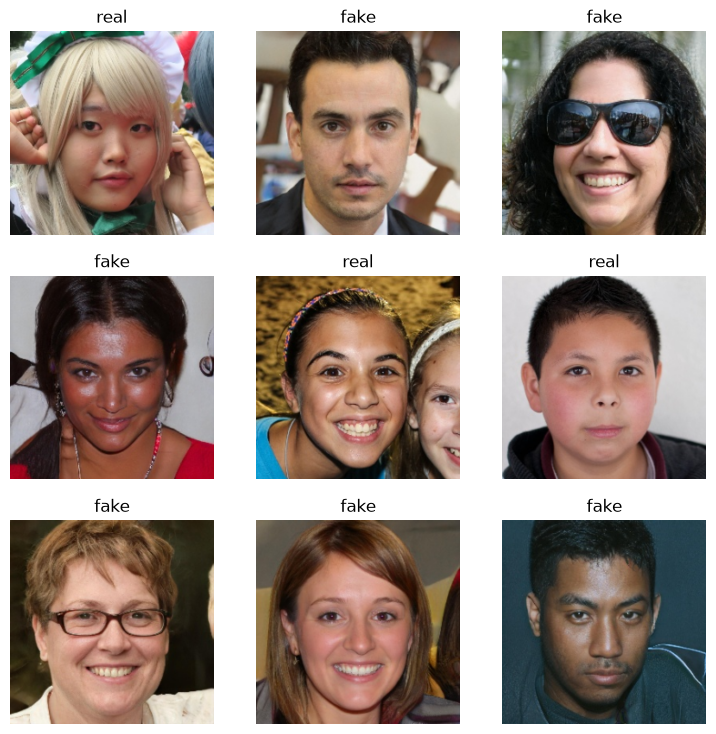

In [12]:
dls = ImageDataLoaders.from_folder(path, train='train', valid='valid', item_tfms=Resize(224))


dls.vocab

dls.show_batch(max_n=9)

<div></div>

SuggestedLRs(valley=0.002511886414140463)

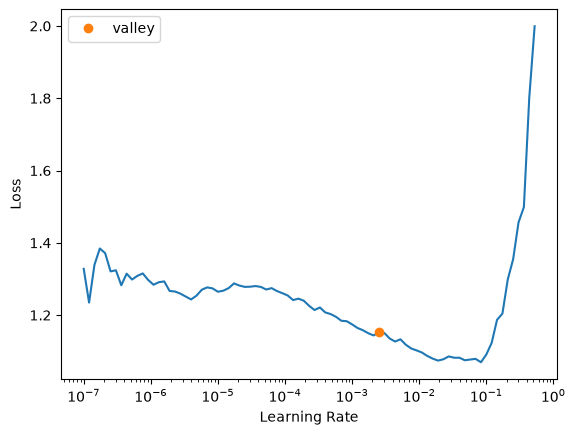

In [14]:
learn = vision_learner(dls, resnet34, metrics=error_rate)

learn.lr_find()

In [17]:
learn.fine_tune(3, base_lr =1.4e-3)

epoch,train_loss,valid_loss,error_rate,time
0,0.255535,0.198562,0.079400,06:27


epoch,train_loss,valid_loss,error_rate,time
0,0.055129,0.029983,0.011650,08:45
1,0.016894,0.016219,0.005250,08:46
2,0.002246,0.006151,0.002550,08:42


from fastai.callback.tracker import SaveModelCallback

learn.fine_tune(3, base_lr=1.4e-3,
                cbs=SaveModelCallback(monitor='valid_loss', fname='best_model'))

learn.load('best_model')   # <- pulls back whichever epoch had the lowest valid_loss

This is what claude said to do for next time lets me save the best verision of the model next time so i don;t overfit. 

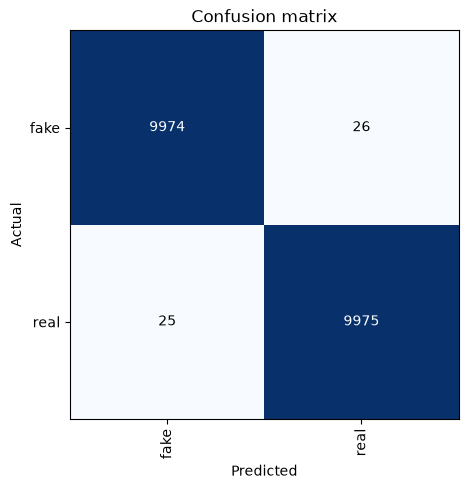

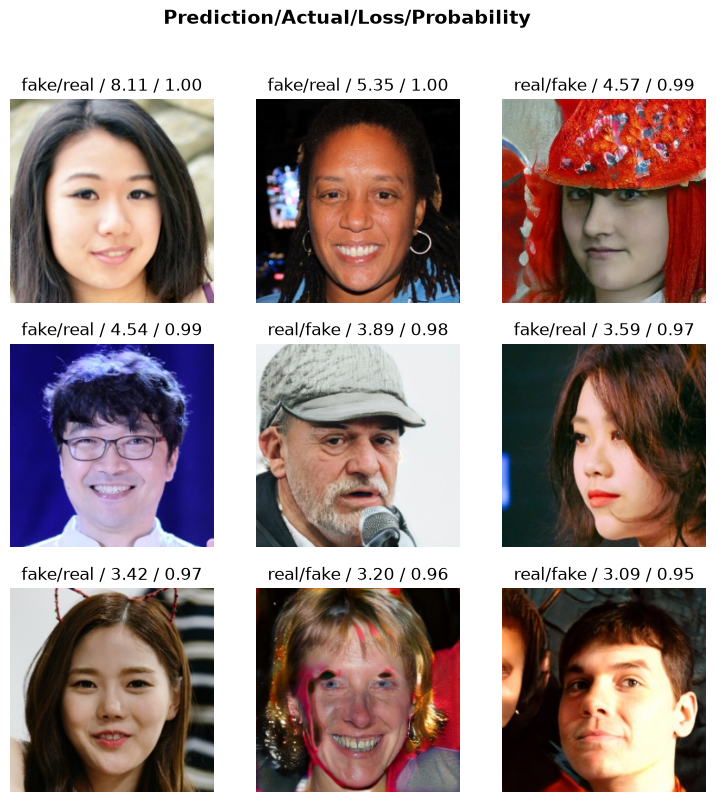

In [18]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.plot_top_losses(9, nrows=3)

In [19]:
import os

# Check current directory
print("Working directory:", os.getcwd())

# Try the export with explicit path
try:
    learn.export("/Users/shshankj/Desktop/52_Hard/DeepFakeDetector/model.pkl")
    print("Export completed")
    
    # Check if file exists
    if os.path.exists("model.pkl"):
        size = os.path.getsize("model.pkl")
        print(f"✅ File created! Size: {size / (1024**2):.1f} MB")
    else:
        print("❌ File not found after export")
        
except Exception as e:
    print(f"❌ Export failed: {e}")

Working directory: /Users/shshankj/Desktop/52_Hard/DeepFakeDetector
Export completed
✅ File created! Size: 85.5 MB


In [20]:
learn.predict('fk1.jpg')

('real', tensor(1), tensor([8.6839e-05, 9.9991e-01]))

In [21]:
learn.predict('mobile-05.jpg')

('fake', tensor(0), tensor([0.7146, 0.2854]))

In [22]:
learn.predict('mobile-06.jpg')

('real', tensor(1), tensor([1.8381e-12, 1.0000e+00]))

In [23]:
learn.predict('mobile-07.jpg')

('fake', tensor(0), tensor([0.9571, 0.0429]))

In [24]:
learn.predict('mobile-08.jpg')

('real', tensor(1), tensor([5.5351e-07, 1.0000e+00]))

Honest conclusions, the data i had to train on was quite old, its not incapable of being able to detect modern deepfakes (talking like modern has a life cycle of 6 months), all of the new sample i used of fake ai people the model really did get it 50-50, which is not good enough and might suggest my model was overfit, but i think it primarily came down to my model being based on quite old data. 